In [162]:
from toy_model import *
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from functools import partial
from scipy.linalg import orthogonal_procrustes

In [143]:
def plot_pca(activation: torch.Tensor, dataset: MarkovData, n=3, figsize=(7,6), only_model=False, state_colour=False):
    X=np.stack(activation)
    X=X.reshape(X.shape[0]*X.shape[1], X.shape[2])
    X=X-np.mean(X,axis=0,keepdims=True)
    states=[s[:-1] for s in dataset.states]
    states_flat=np.concatenate(states,axis=0)
    states_rounded = np.round(states_flat, decimals=3)  
    _, states_labels = np.unique(states_rounded, axis=0, return_inverse=True)

    unique_states = np.unique(states_rounded, axis=0)
    if not only_model:
        print('Label -> State vector')
        for label, vec in enumerate(unique_states):
            print(f'{label} -> {vec}')

    #print("Number of unique states:", len(np.unique(states_labels)))
    #print(np.unique(states_labels))
    #print("State labels shape:", states_labels.shape)
    
    def plot(X, s=1):
        pca = PCA(n_components=n)
        X_reduced = pca.fit_transform(X)  # X.shape = (n_samples, hidden_dim)

        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot(111, projection='3d') if n == 3 else fig.add_subplot()

        if state_colour:
            scatter_fn = partial(ax.scatter, c=states_flat)
        else:
            scatter_fn = partial(ax.scatter, c=states_labels, cmap='tab10')
        if n==3:
            scatter = scatter_fn(X_reduced[:,0], X_reduced[:,1], X_reduced[:,2], s=s, alpha=0.7)
        else:
            scatter = scatter_fn(X_reduced[:,0], X_reduced[:,1], s=s, alpha=0.7)

        # Add legend
        if not state_colour:
            legend1 = ax.legend(*scatter.legend_elements(), title="States")
            ax.add_artist(legend1)

        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        if n==3: ax.set_zlabel("PC3")
        return fig
    
    # Plotting Markov's simplex
    if not only_model: plot(states_flat, 5)

    # Plotting model's activations
    return plot(X)

In [144]:
T0 = np.array([
    [0, 1, 0],
    [0, 0, 0],
    [0.5, 0, 0]
])
T1 = np.array([
    [0, 0, 0],
    [0, 0, 1],
    [0.5, 0, 0]
])

dataset = MarkovData(1000, 30, 3, 2, [T0, T1])

Label -> State vector
0 -> [0. 0. 1.]
1 -> [0. 1. 0.]
2 -> [0.333 0.    0.667]
3 -> [0.333 0.333 0.333]
4 -> [0.333 0.667 0.   ]
5 -> [0.5 0.5 0. ]
6 -> [1. 0. 0.]


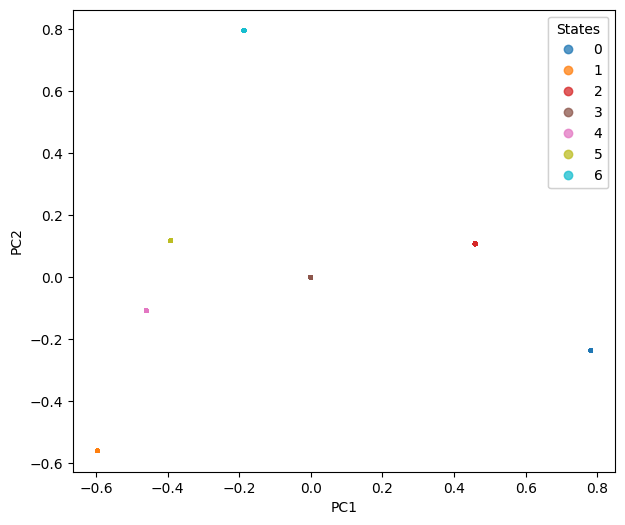

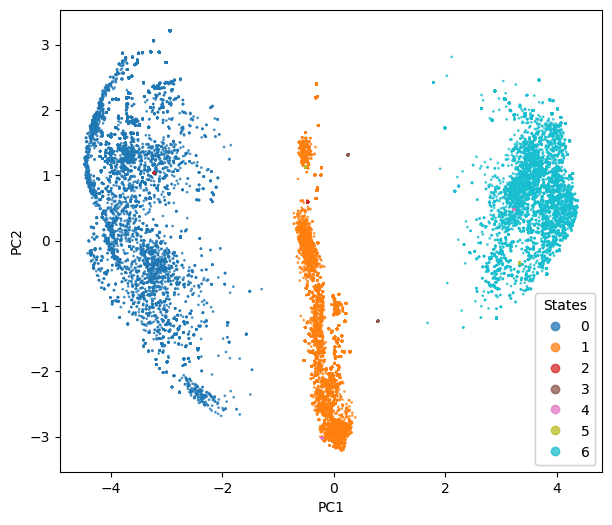

In [145]:
model = load_model('Jayden/model_0.pt', 'Jayden/model_cfg.pt')
model.eval()
with torch.no_grad():
    logits, cache = model.run_with_cache(torch.stack(dataset.data))
activation = cache['ln_final.hook_normalized'].to("cpu")
plot_pca(activation, dataset, 2)
plt.show()

Epoch: 5
Label -> State vector
0 -> [0. 0. 1.]
1 -> [0. 1. 0.]
2 -> [0.333333 0.       0.666667]
3 -> [0.333333 0.333333 0.333333]
4 -> [0.333333 0.666667 0.      ]
5 -> [0.5 0.5 0. ]
6 -> [1. 0. 0.]


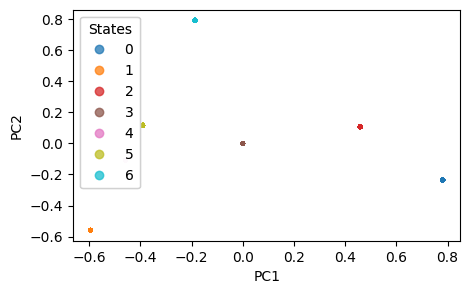

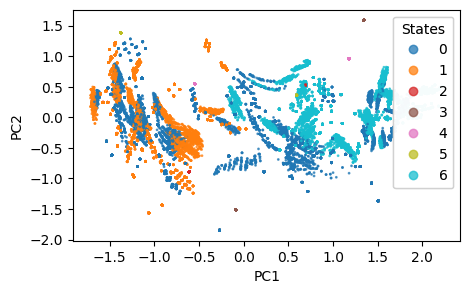

Epoch: 10


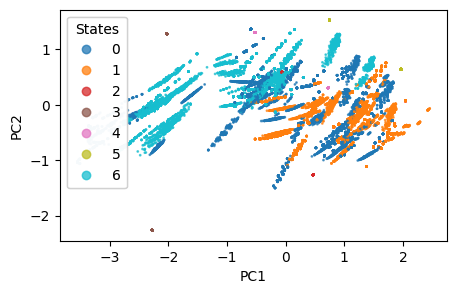

Epoch: 15


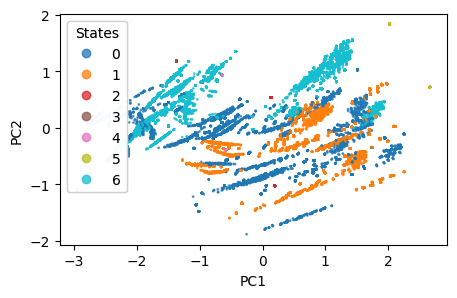

Epoch: 20


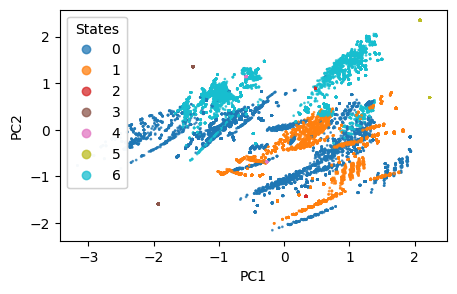

Epoch: 25


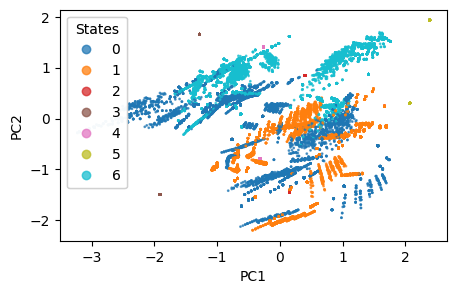

Epoch: 30


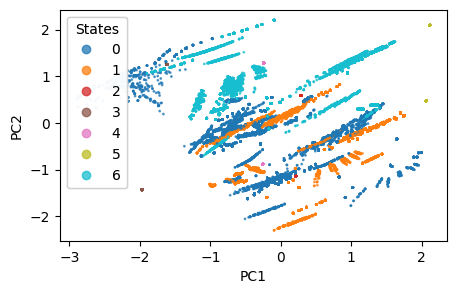

Epoch: 35


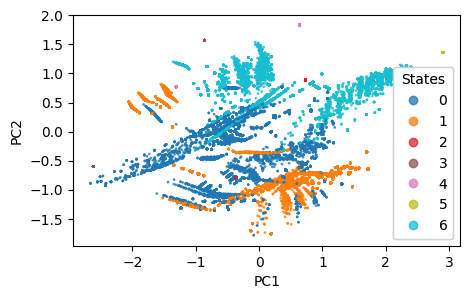

Epoch: 40


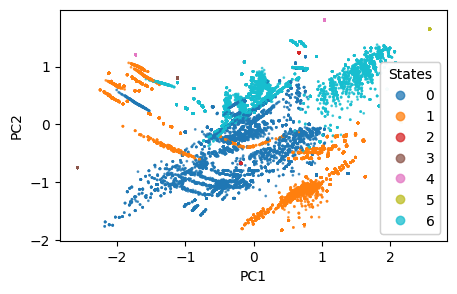

Epoch: 45


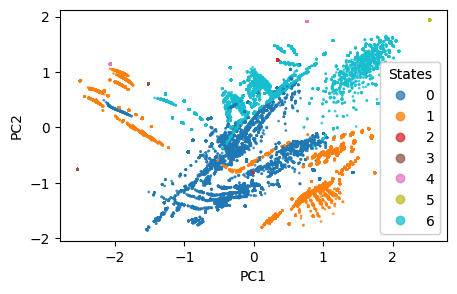

Epoch: 50


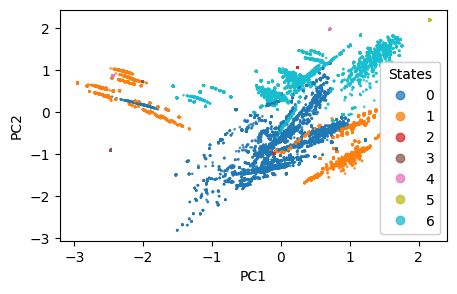

Epoch: 55


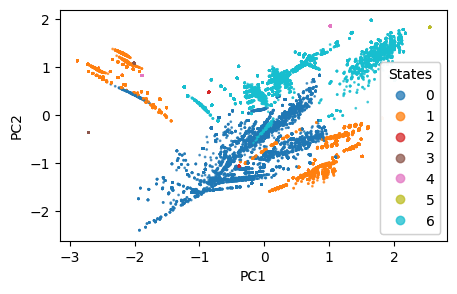

Epoch: 60


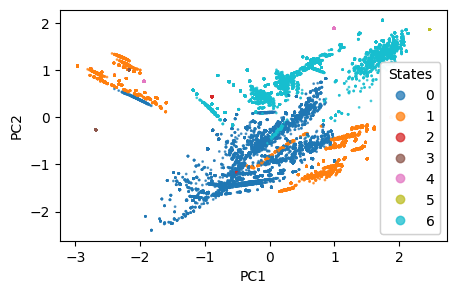

Epoch: 65


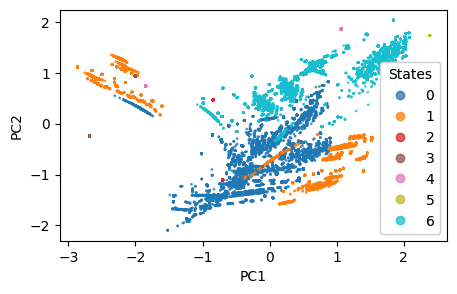

Epoch: 70


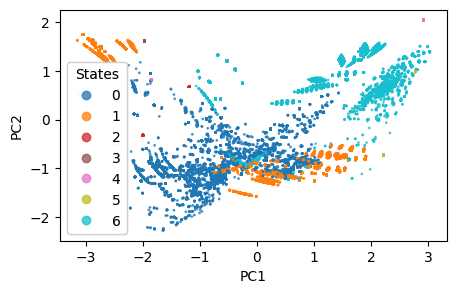

Epoch: 75


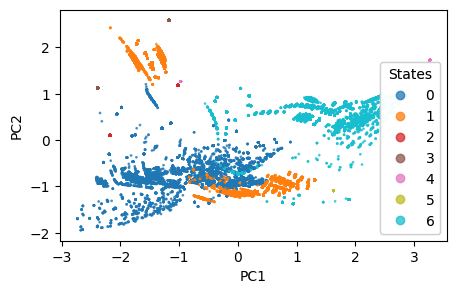

Epoch: 80


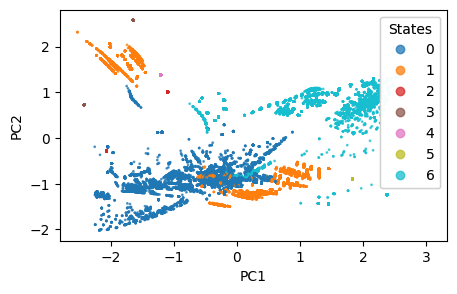

Epoch: 85


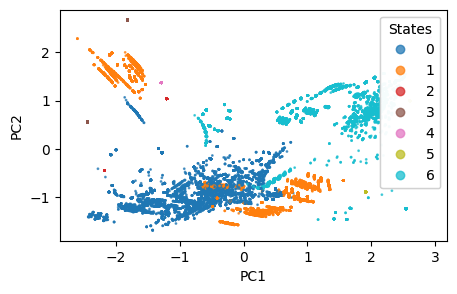

Epoch: 90


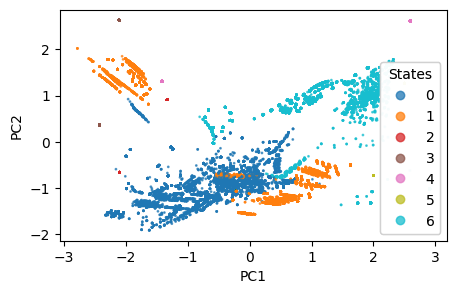

Epoch: 95


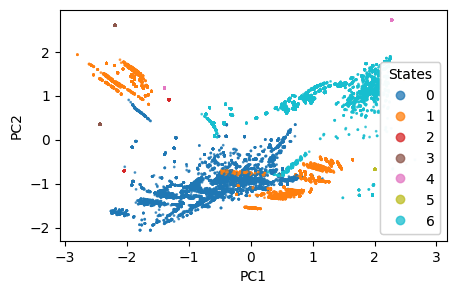

Epoch: 100


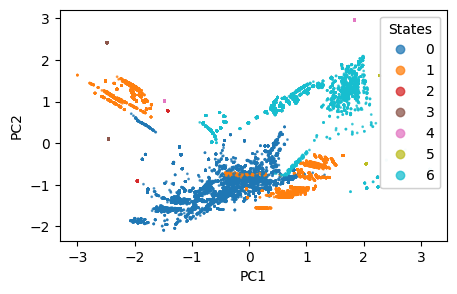

Epoch: 105


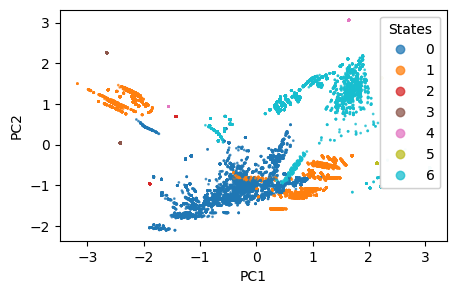

Epoch: 110


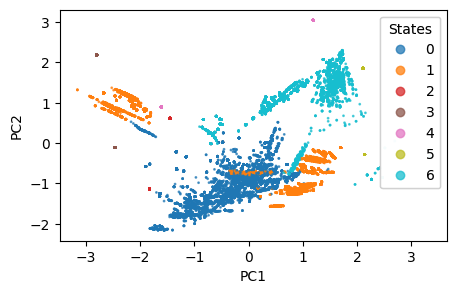

Epoch: 115


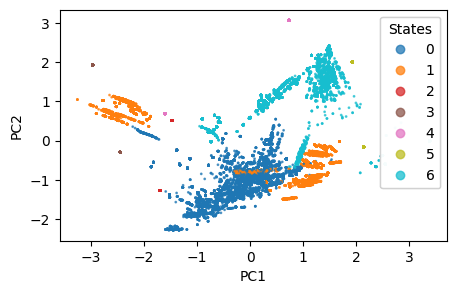

Epoch: 120


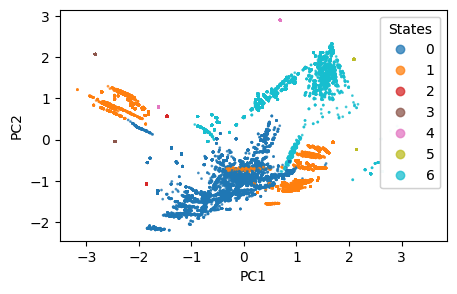

Epoch: 125


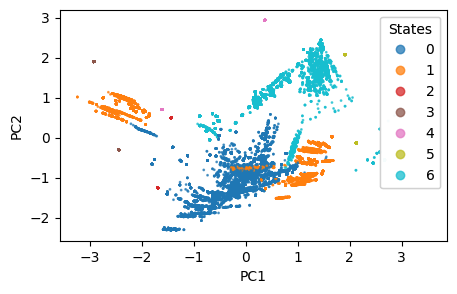

Epoch: 130


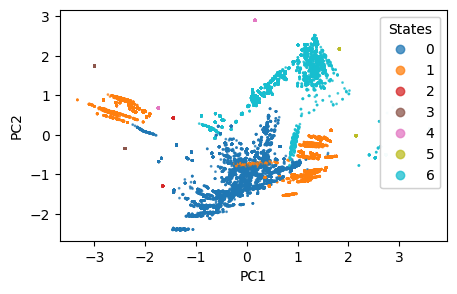

Epoch: 135


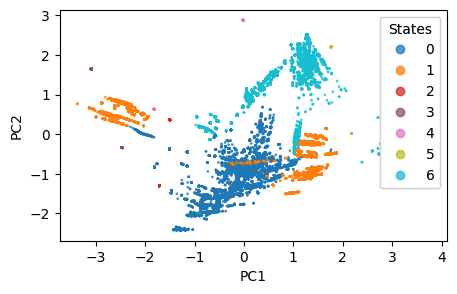

Epoch: 140


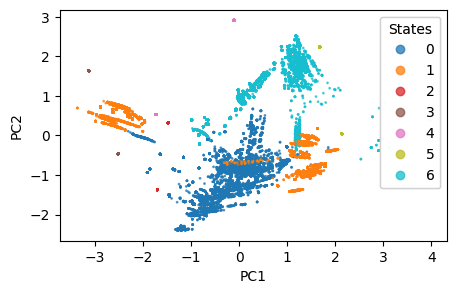

Epoch: 145


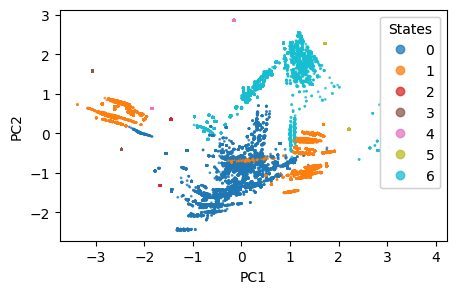

Epoch: 150


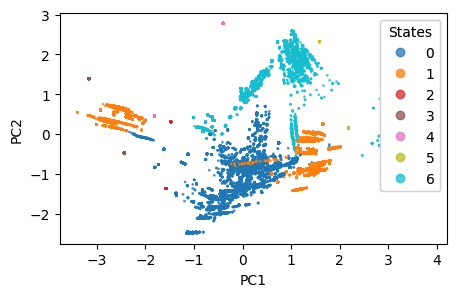

Epoch: 155


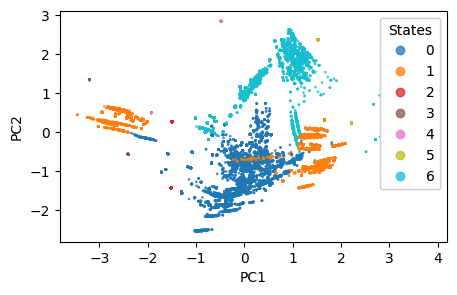

Epoch: 160


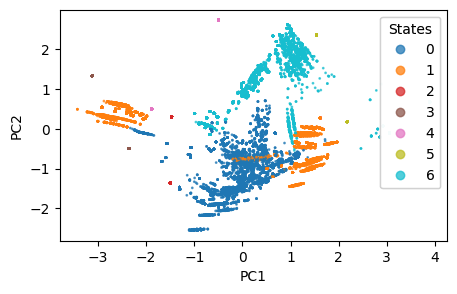

Epoch: 165


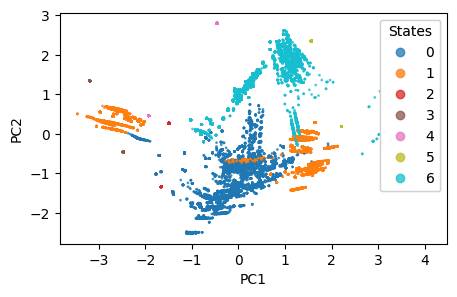

Epoch: 170


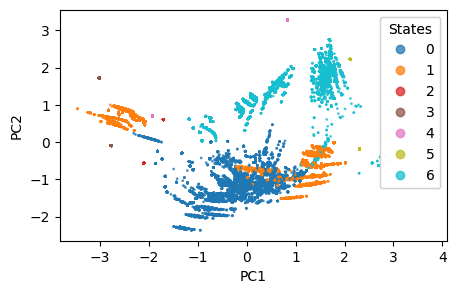

Epoch: 175


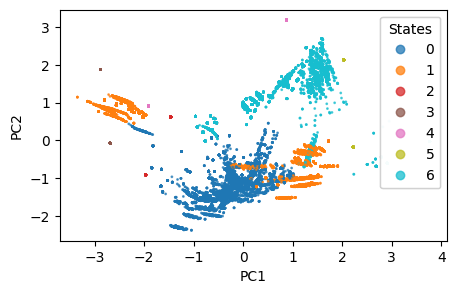

Epoch: 180


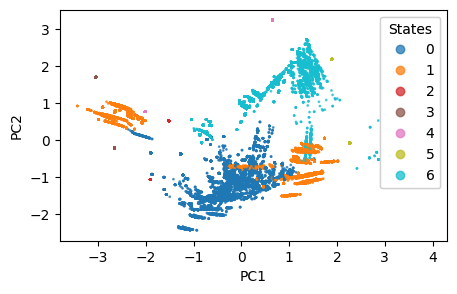

Epoch: 185


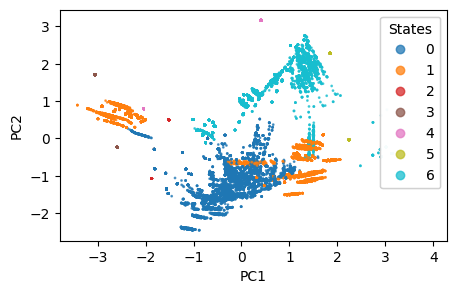

Epoch: 190


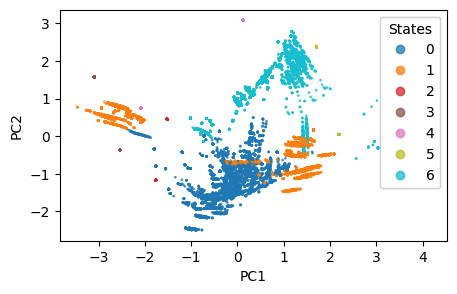

Epoch: 195


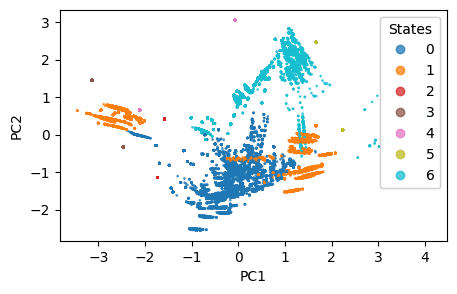

Epoch: 200


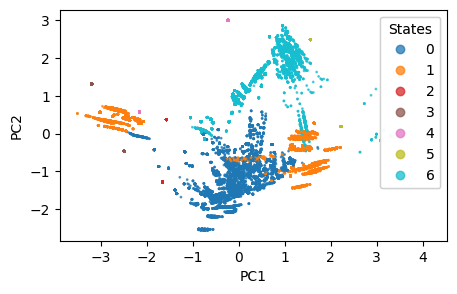

Epoch: 205


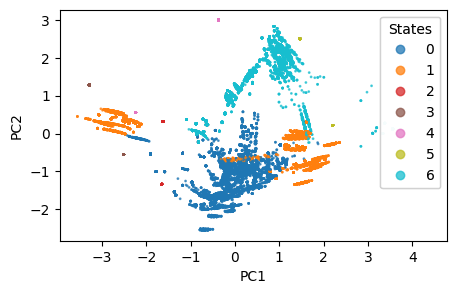

Epoch: 210


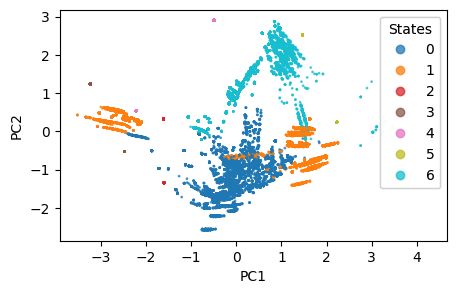

Epoch: 215


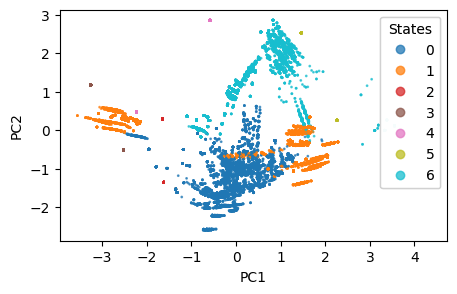

Epoch: 220


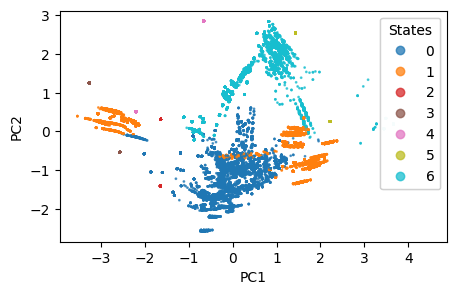

Epoch: 225


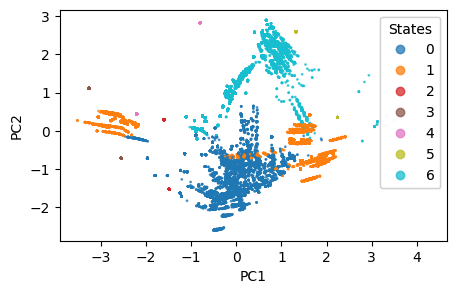

Epoch: 230


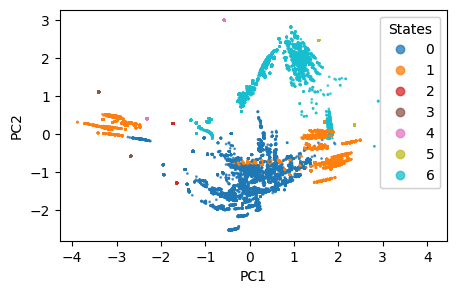

Epoch: 235


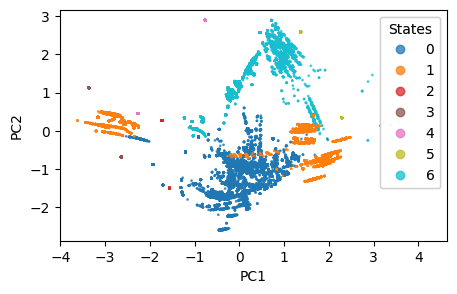

Epoch: 240


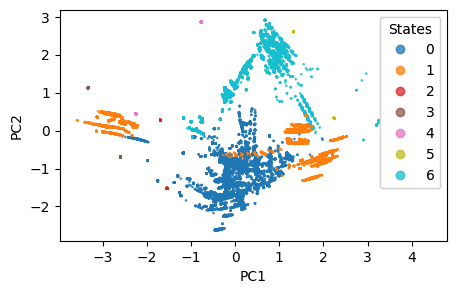

Epoch: 245


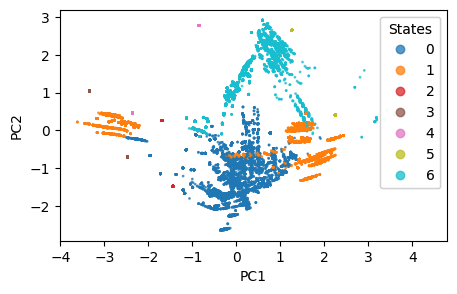

Epoch: 250


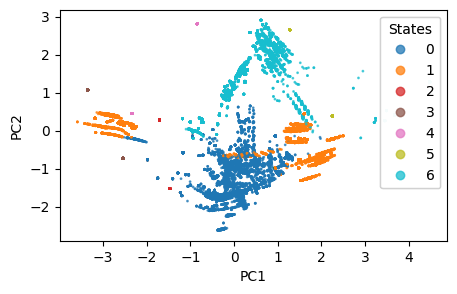

Epoch: 255


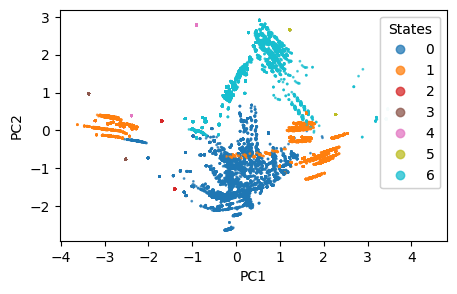

Epoch: 260


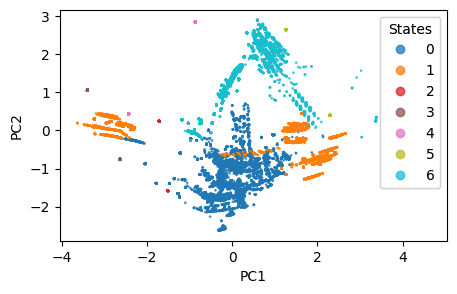

Epoch: 265


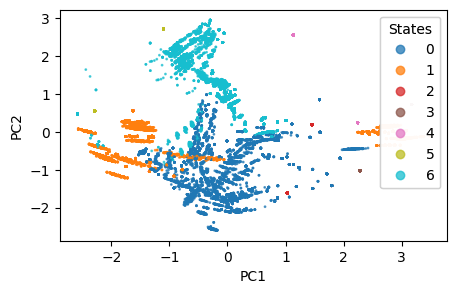

Epoch: 270


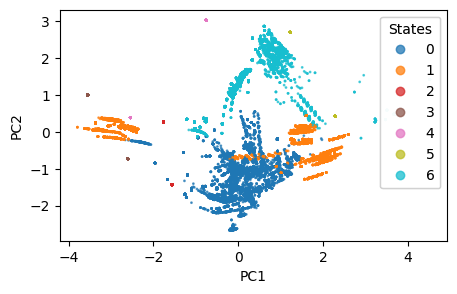

Epoch: 275


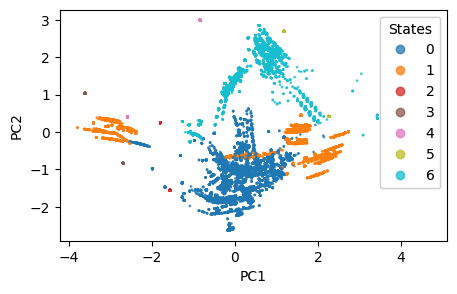

Epoch: 280


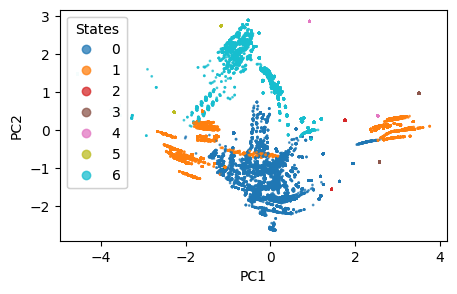

Epoch: 285


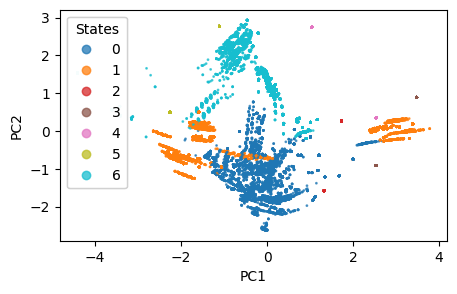

Epoch: 290


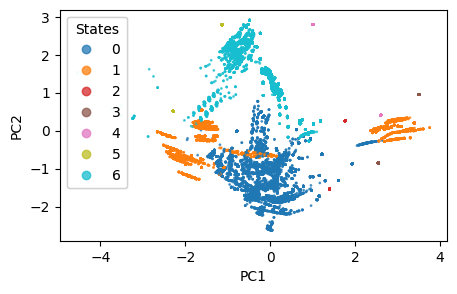

Epoch: 295


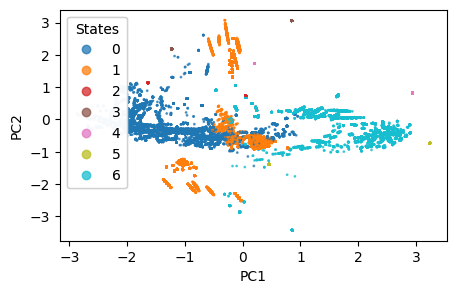

Epoch: 300


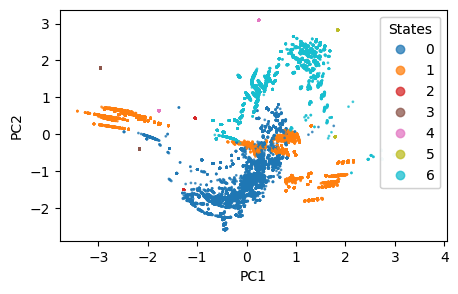

In [ ]:
for epoch in range(5,305,5):
    model = load_model(f'D1/model_{epoch}.pt', 'D1/model_cfg.pt')
    model.eval()
    with torch.no_grad():
        logits, cache = model.run_with_cache(torch.stack(dataset.data))
    activation = cache['blocks.0.hook_resid_post'].to("cpu")
    print('Epoch:', epoch)
    plot_pca(activation, dataset, 2, (5,3), epoch!=5)
plt.show()

Epoch: 5
Label -> State vector
0 -> [0. 0. 1.]
1 -> [0. 1. 0.]
2 -> [0.333333 0.       0.666667]
3 -> [0.333333 0.333333 0.333333]
4 -> [0.333333 0.666667 0.      ]
5 -> [0.5 0.5 0. ]
6 -> [1. 0. 0.]


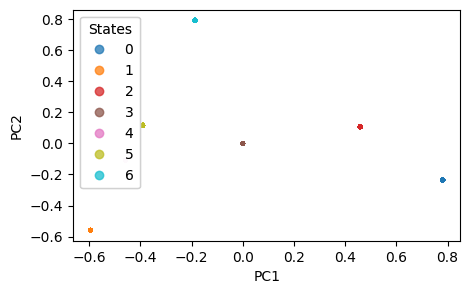

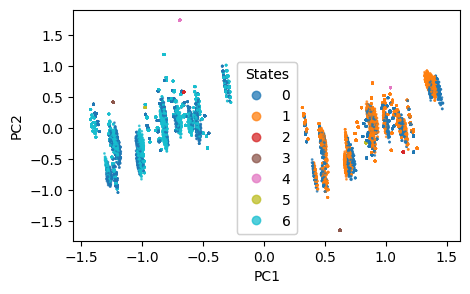

Epoch: 10


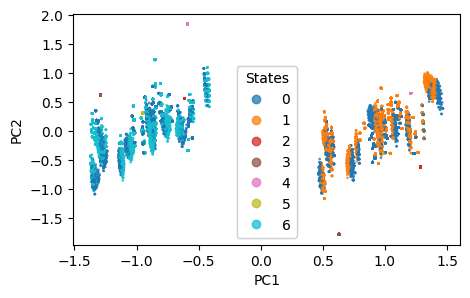

Epoch: 15


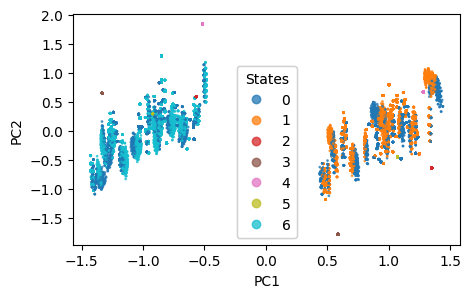

Epoch: 20


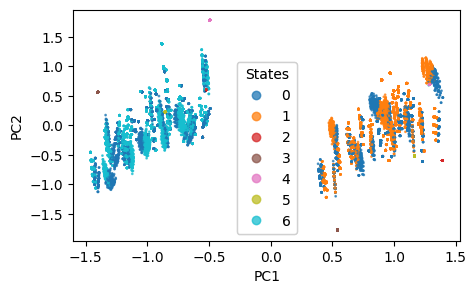

Epoch: 25


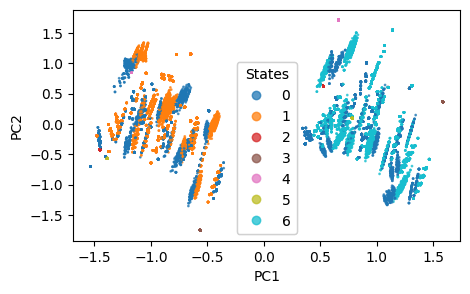

Epoch: 30


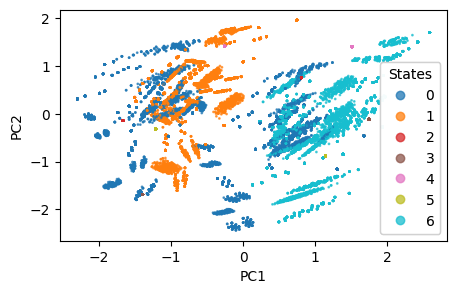

Epoch: 35


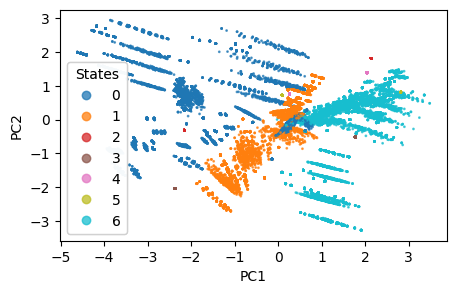

Epoch: 40


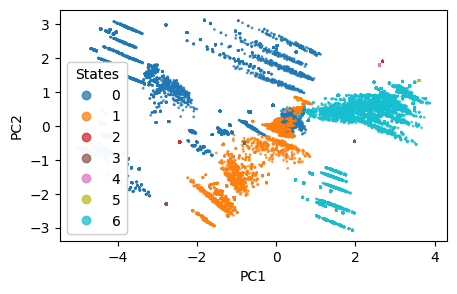

Epoch: 45


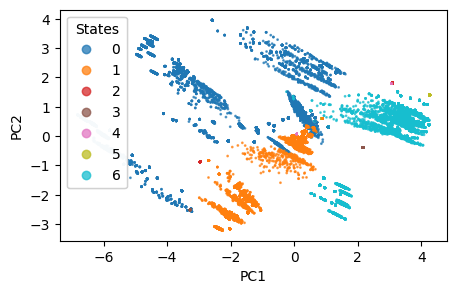

Epoch: 50


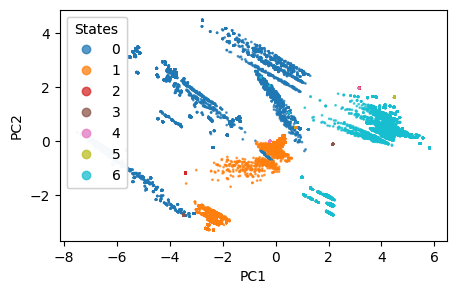

Epoch: 55


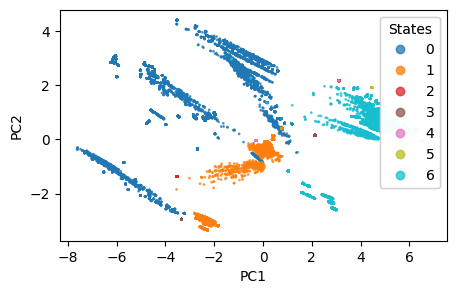

Epoch: 60


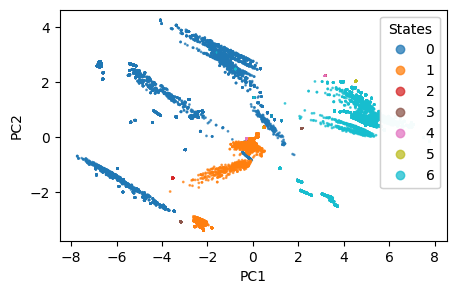

Epoch: 65


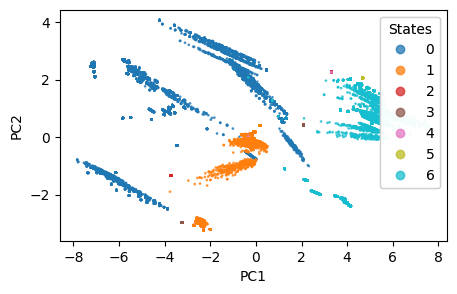

Epoch: 70


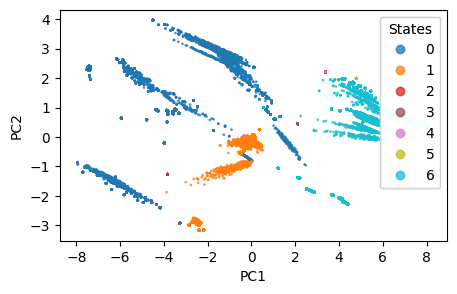

Epoch: 75


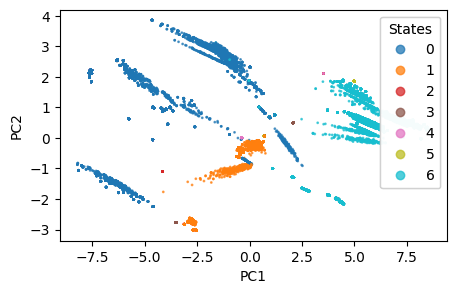

Epoch: 80


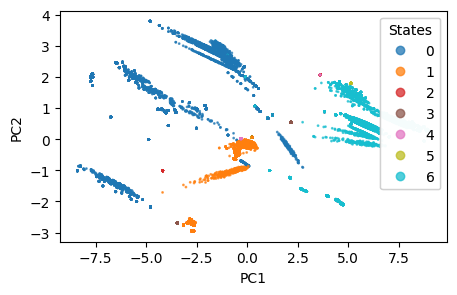

Epoch: 85


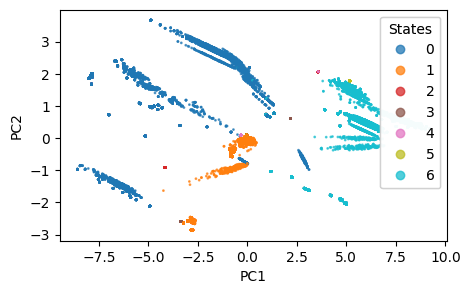

Epoch: 90


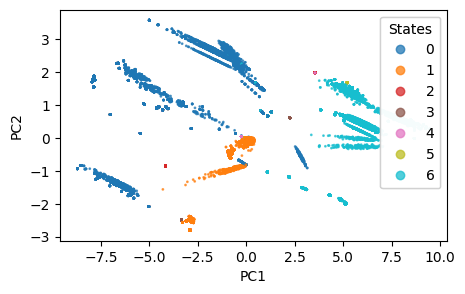

Epoch: 95


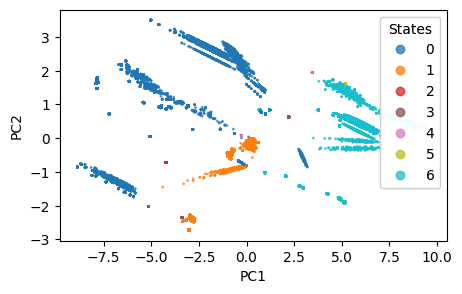

Epoch: 100


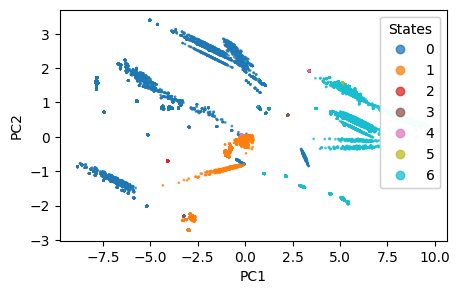

Epoch: 105


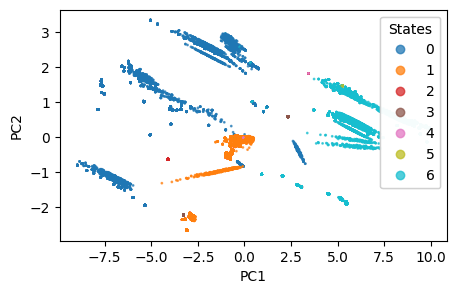

Epoch: 110


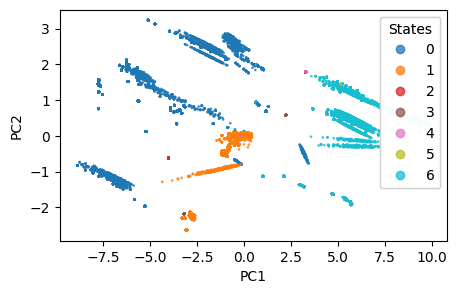

Epoch: 115


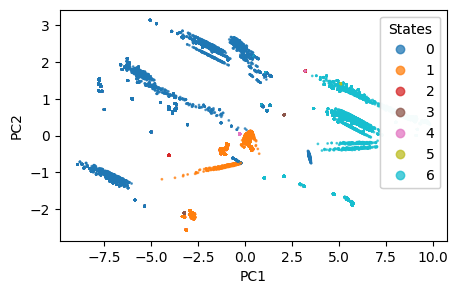

Epoch: 120


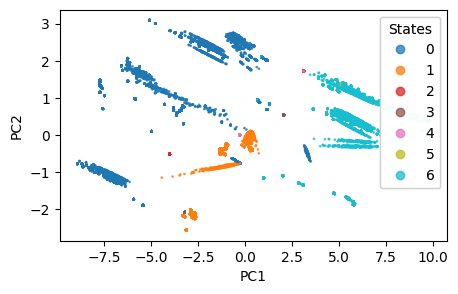

Epoch: 125


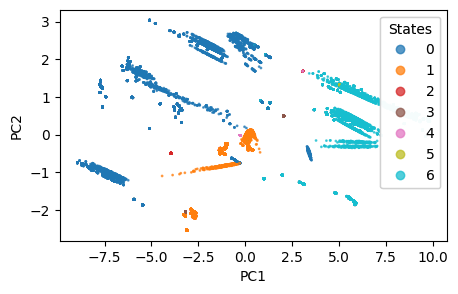

Epoch: 130


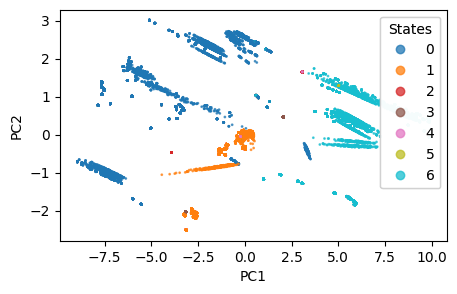

Epoch: 135


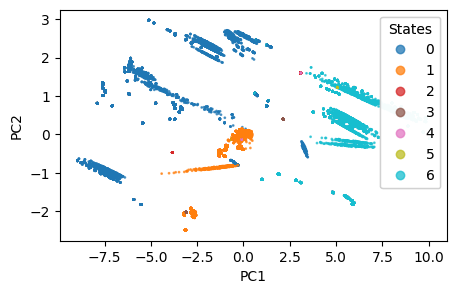

Epoch: 140


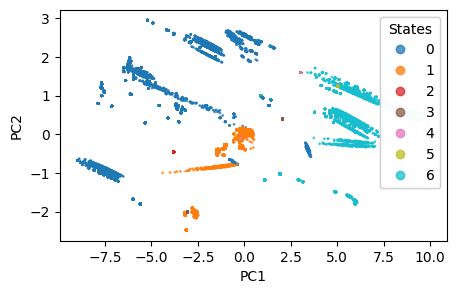

Epoch: 145


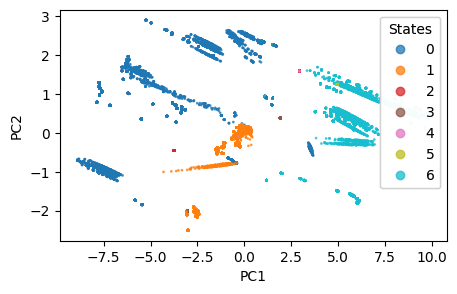

Epoch: 150


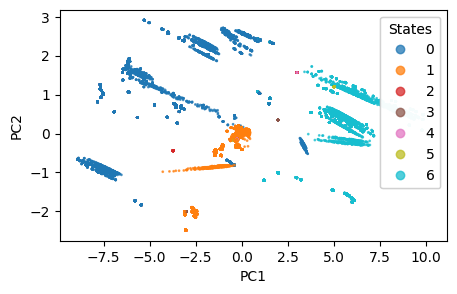

Epoch: 155


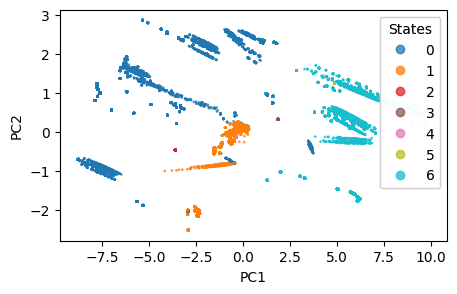

Epoch: 160


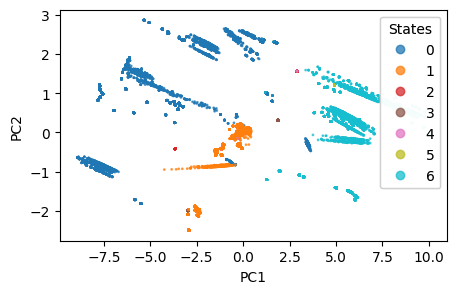

Epoch: 165


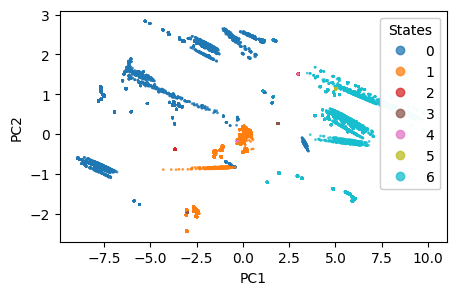

Epoch: 170


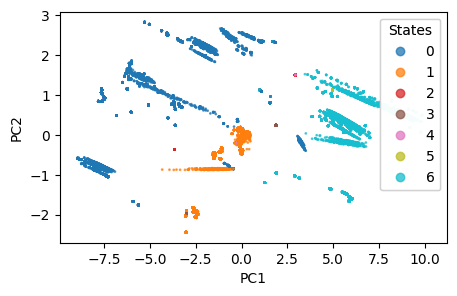

Epoch: 175


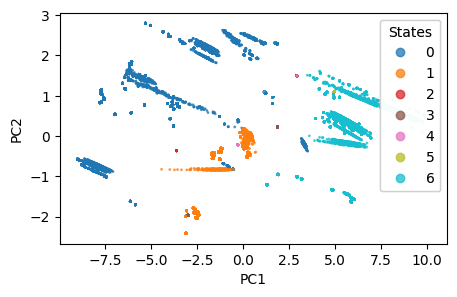

Epoch: 180


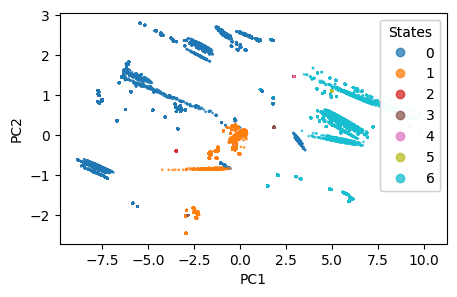

Epoch: 185


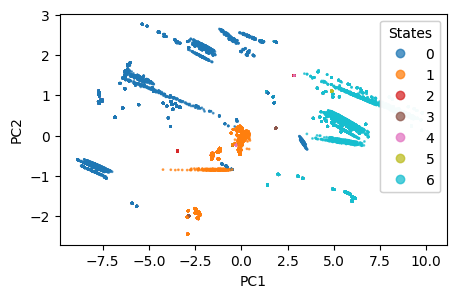

Epoch: 190


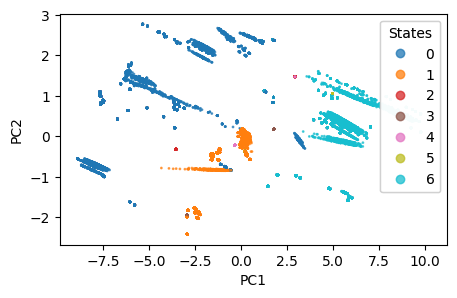

Epoch: 195


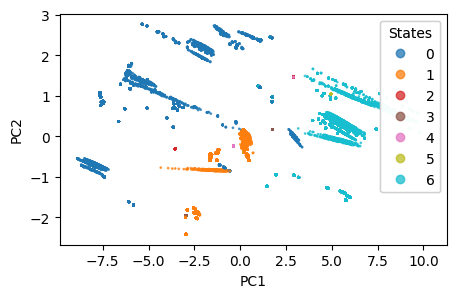

Epoch: 200


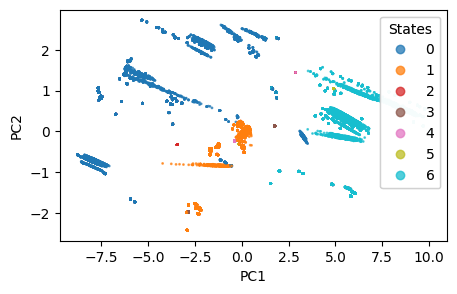

Epoch: 205


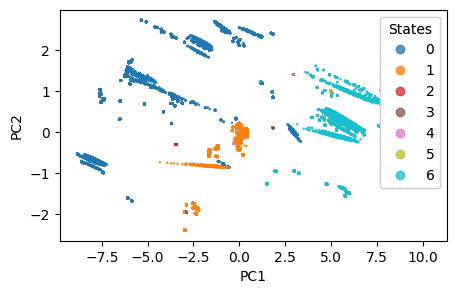

Epoch: 210


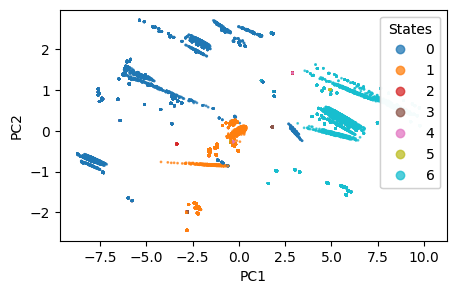

Epoch: 215


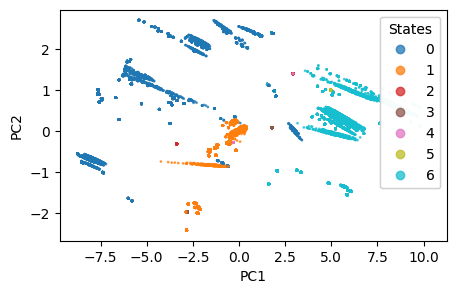

Epoch: 220


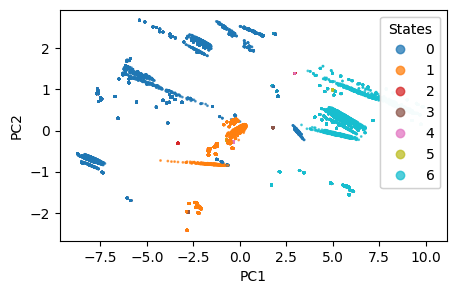

Epoch: 225


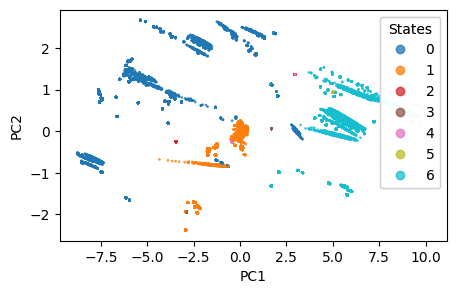

Epoch: 230


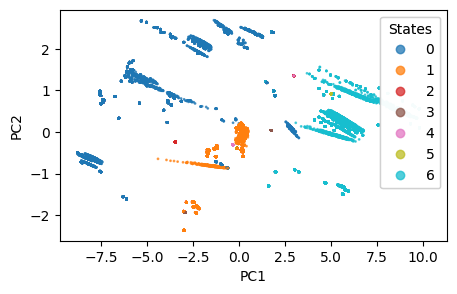

Epoch: 235


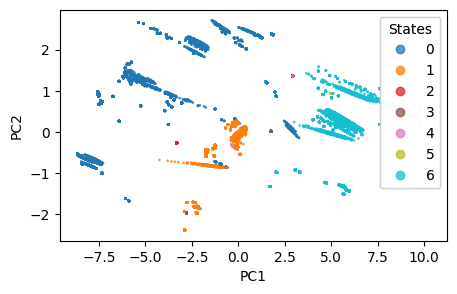

Epoch: 240


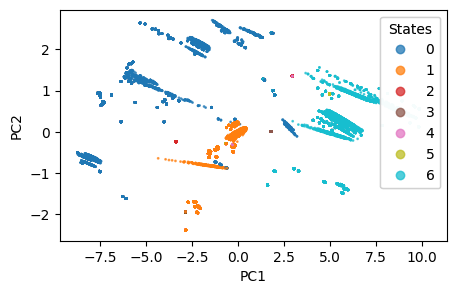

Epoch: 245


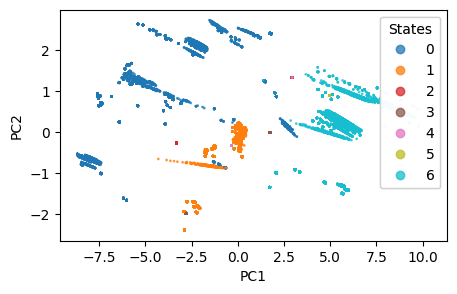

Epoch: 250


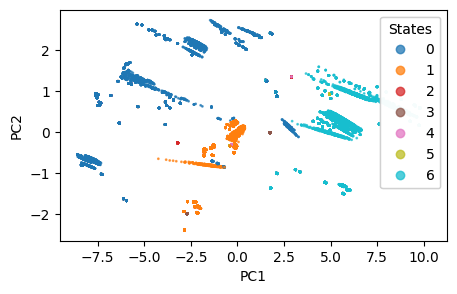

Epoch: 255


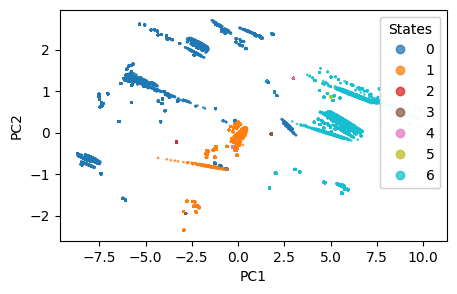

Epoch: 260


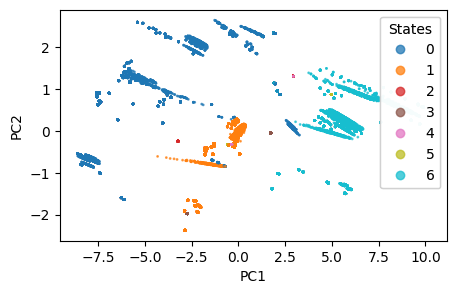

Epoch: 265


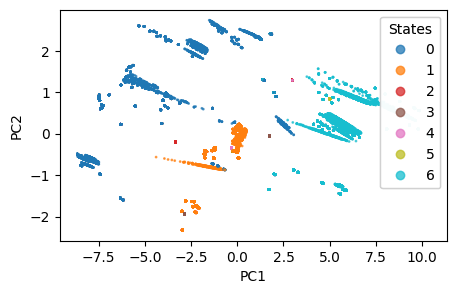

Epoch: 270


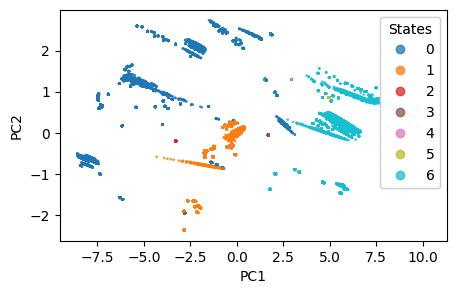

Epoch: 275


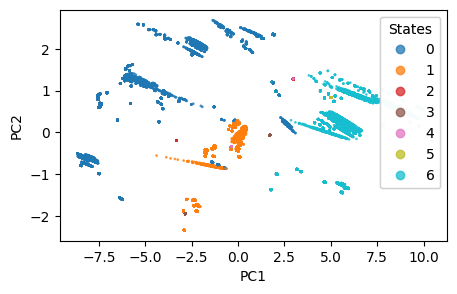

Epoch: 280


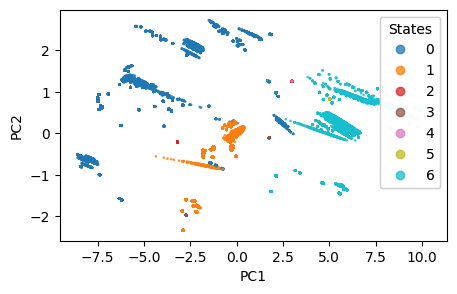

Epoch: 285


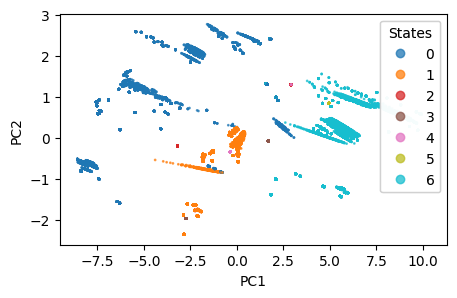

Epoch: 290


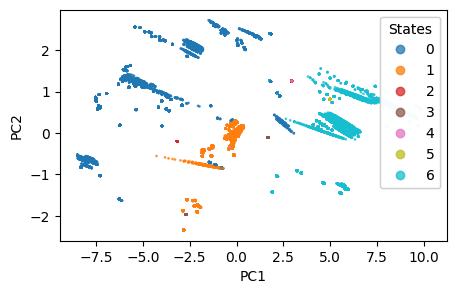

Epoch: 295


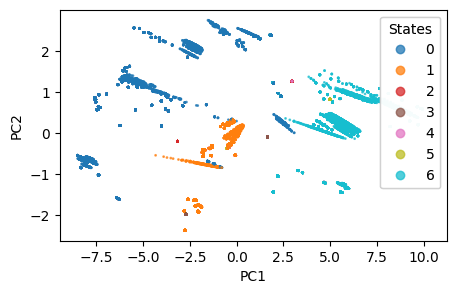

Epoch: 300


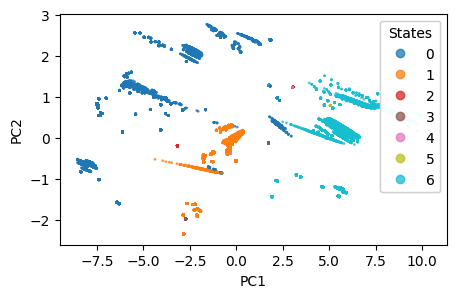

In [48]:
for epoch in range(5,305,5):
    model = load_model(f'A1/model_{epoch}.pt', 'A1/model_cfg.pt')
    model.eval()
    with torch.no_grad():
        logits, cache = model.run_with_cache(torch.stack(dataset.data))
    activation = cache['blocks.0.hook_resid_post'].to("cpu")
    print('Epoch:', epoch)
    plot_pca(activation, dataset, 2, (5,3), epoch!=5)

In [146]:
T0 = np.array([
    [0.00001, 0.99995, 0.00001],
    [0.00001, 0.00001, 0.00001],
    [0.49998, 0.00001, 0.00001]
])
T1 = np.array([
    [0.00001, 0.00001, 0.00001],
    [0.00001, 0.00001, 0.99995],
    [0.49998, 0.00001, 0.00001]
])

dataset = MarkovData(1000, 30, 3, 2, [T0, T1])

Epoch: 5
Label -> State vector
0 -> [0. 0. 1.]
1 -> [0. 1. 0.]
2 -> [0.1 0.  0.9]
3 -> [0.111 0.    0.889]
4 -> [0.143 0.    0.857]
5 -> [0.154 0.077 0.769]
6 -> [0.2 0.1 0.7]
7 -> [0.214 0.643 0.143]
8 -> [0.231 0.615 0.154]
9 -> [0.25 0.75 0.  ]
10 -> [0.273 0.545 0.182]
11 -> [0.333 0.    0.667]
12 -> [0.333 0.333 0.333]
13 -> [0.333 0.667 0.   ]
14 -> [0.429 0.143 0.429]
15 -> [0.5 0.5 0. ]
16 -> [0.6 0.  0.4]
17 -> [0.636 0.364 0.   ]
18 -> [0.714 0.286 0.   ]
19 -> [0.75 0.25 0.  ]
20 -> [0.8 0.2 0. ]
21 -> [0.818 0.182 0.   ]
22 -> [1. 0. 0.]


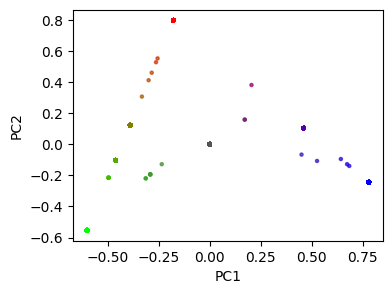

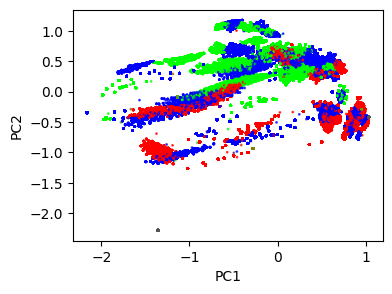

Epoch: 45


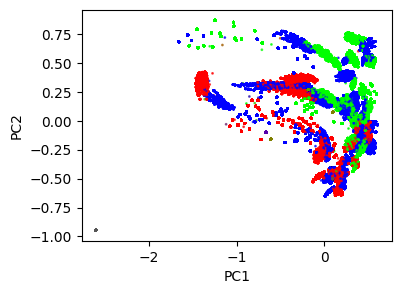

Epoch: 85


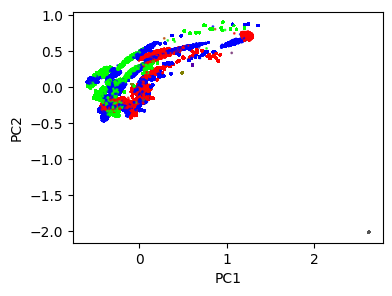

Epoch: 125


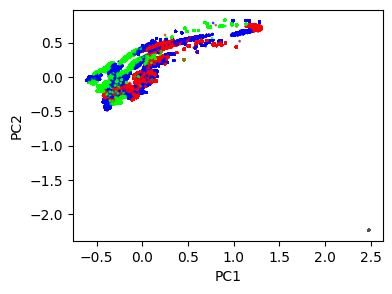

Epoch: 165


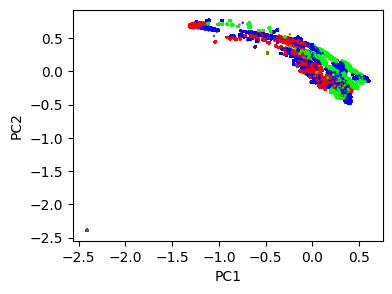

Epoch: 205


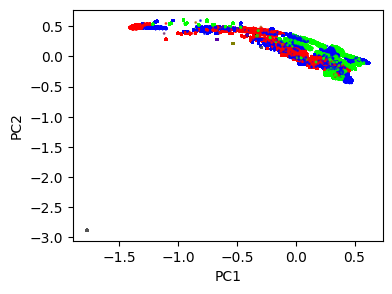

Epoch: 245


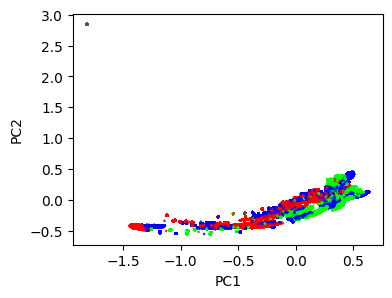

Epoch: 285


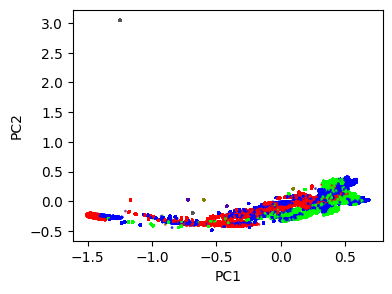

Epoch: 325


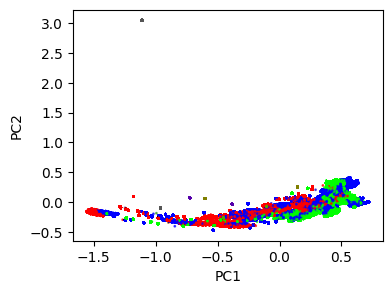

Epoch: 365


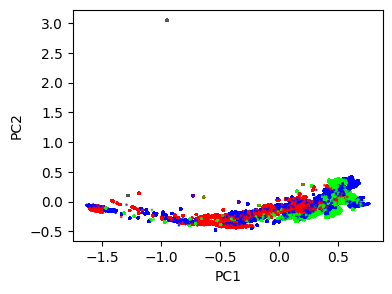

Epoch: 5
Label -> State vector
0 -> [0. 0. 1.]
1 -> [0. 1. 0.]
2 -> [0.1 0.  0.9]
3 -> [0.111 0.    0.889]
4 -> [0.143 0.    0.857]
5 -> [0.154 0.077 0.769]
6 -> [0.2 0.1 0.7]
7 -> [0.214 0.643 0.143]
8 -> [0.231 0.615 0.154]
9 -> [0.25 0.75 0.  ]
10 -> [0.273 0.545 0.182]
11 -> [0.333 0.    0.667]
12 -> [0.333 0.333 0.333]
13 -> [0.333 0.667 0.   ]
14 -> [0.429 0.143 0.429]
15 -> [0.5 0.5 0. ]
16 -> [0.6 0.  0.4]
17 -> [0.636 0.364 0.   ]
18 -> [0.714 0.286 0.   ]
19 -> [0.75 0.25 0.  ]
20 -> [0.8 0.2 0. ]
21 -> [0.818 0.182 0.   ]
22 -> [1. 0. 0.]


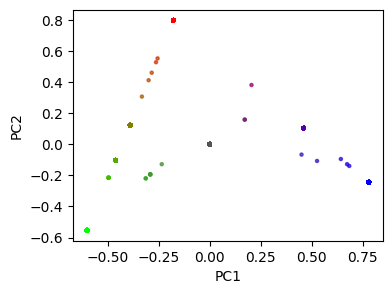

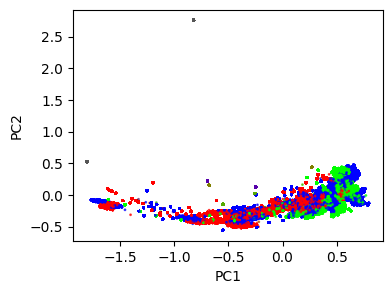

Epoch: 45


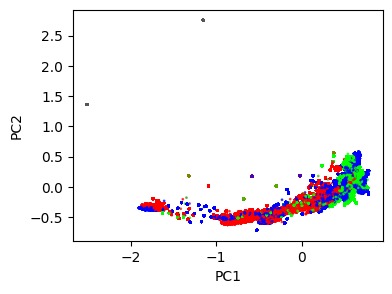

Epoch: 85


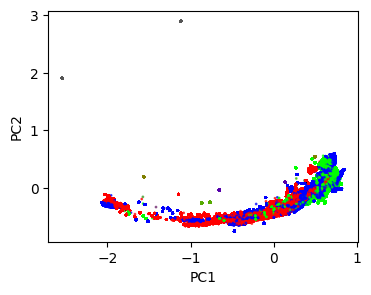

Epoch: 125


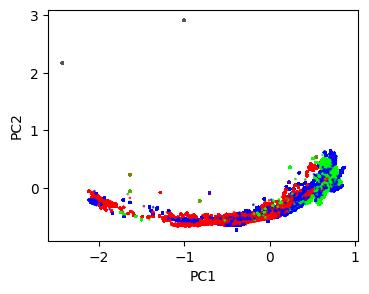

Epoch: 165


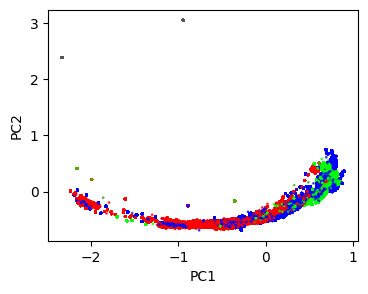

Epoch: 205


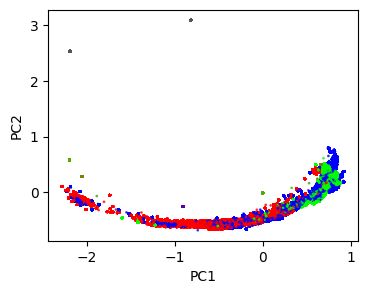

Epoch: 245


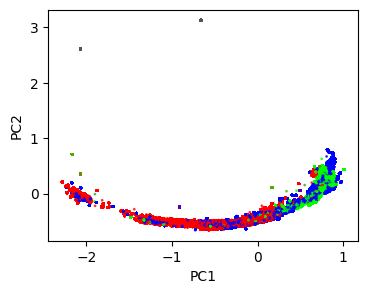

Epoch: 285


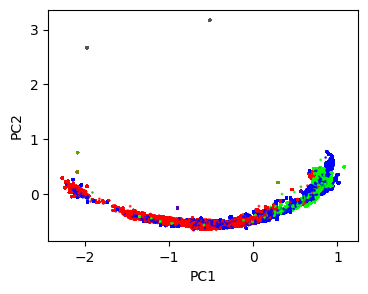

Epoch: 325


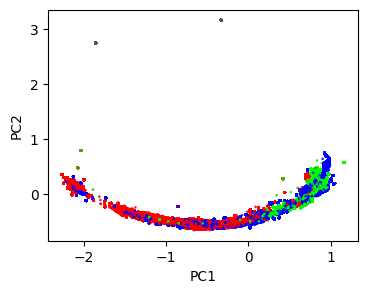

Epoch: 365


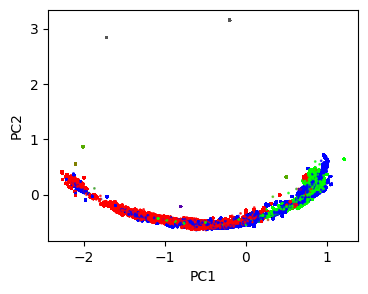

Epoch: 5
Label -> State vector
0 -> [0. 0. 1.]
1 -> [0. 1. 0.]
2 -> [0.1 0.  0.9]
3 -> [0.111 0.    0.889]
4 -> [0.143 0.    0.857]
5 -> [0.154 0.077 0.769]
6 -> [0.2 0.1 0.7]
7 -> [0.214 0.643 0.143]
8 -> [0.231 0.615 0.154]
9 -> [0.25 0.75 0.  ]
10 -> [0.273 0.545 0.182]
11 -> [0.333 0.    0.667]
12 -> [0.333 0.333 0.333]
13 -> [0.333 0.667 0.   ]
14 -> [0.429 0.143 0.429]
15 -> [0.5 0.5 0. ]
16 -> [0.6 0.  0.4]
17 -> [0.636 0.364 0.   ]
18 -> [0.714 0.286 0.   ]
19 -> [0.75 0.25 0.  ]
20 -> [0.8 0.2 0. ]
21 -> [0.818 0.182 0.   ]
22 -> [1. 0. 0.]


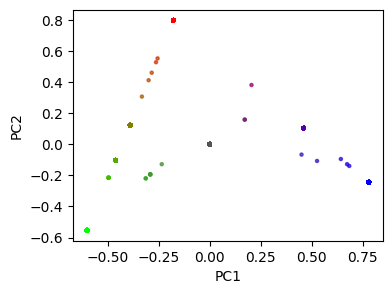

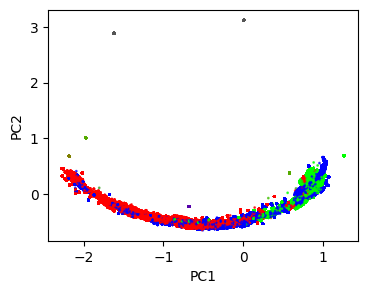

Epoch: 45


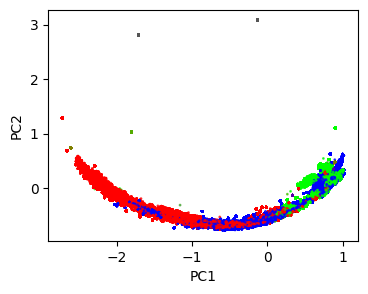

Epoch: 85


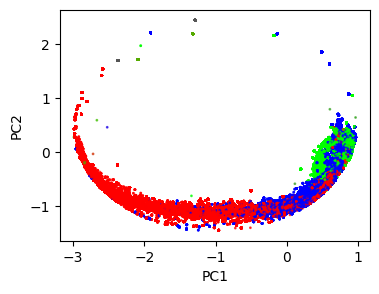

Epoch: 125


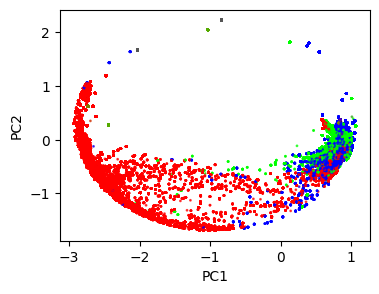

Epoch: 165


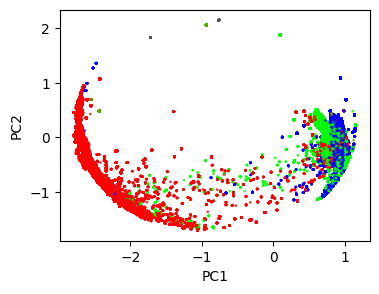

Epoch: 205


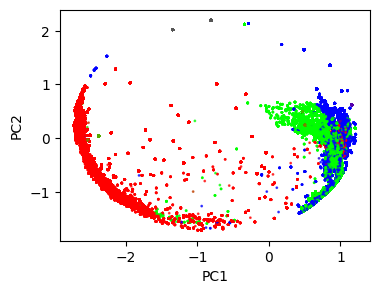

Epoch: 245


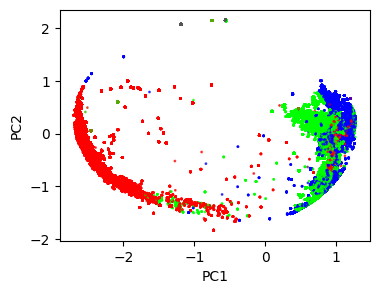

Epoch: 285


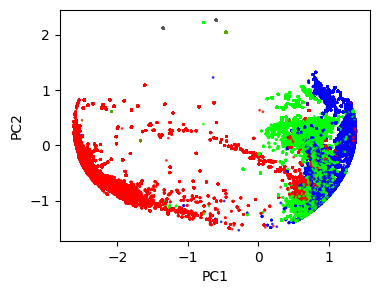

Epoch: 325


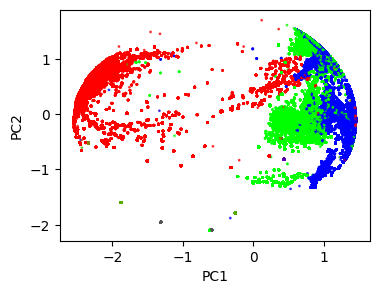

Epoch: 365


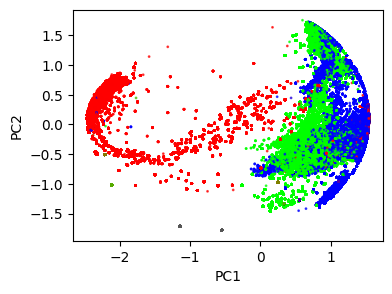

In [87]:
for name in ['Z1R_per', 'Z1R_per_1', 'Z1R_per_2']:
    for epoch in range(5, 405, 40):
        model = load_model(f'{name}/model_{epoch}.pt', 'Z1R_per/model_cfg.pt')
        model.eval()
        with torch.no_grad():
            logits, cache = model.run_with_cache(torch.stack(dataset.data))
        activation = cache['ln_final.hook_normalized'].to("cpu")
        print('Epoch:', epoch)
        plot_pca(activation, dataset, 2, (4,3), epoch!=5, True)

In [167]:
def make_video(activations_gen, dataset, video_name='pca_animation.mp4', n=2):
    states = [s[:-1] for s in dataset.states]
    states_flat = np.concatenate(states, axis=0)
    colors = states_flat

    fig = plt.figure(figsize=(7,6))
    ax = fig.add_subplot(111, projection='3d') if n==3 else fig.add_subplot()

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    if n==3: ax.set_zlabel("PC3")

    pc_prev = None
    aligned_points_prev = None
    frames = []

    # Collect all frames
    for activation in activations_gen:
        X = np.stack(activation)
        X = X.reshape(X.shape[0]*X.shape[1], X.shape[2])
        X = X - np.mean(X, axis=0, keepdims=True)

        pca = PCA(n_components=n)
        X_reduced = pca.fit_transform(X)
        # Alignment
        if pc_prev is not None:
            R, _ = orthogonal_procrustes(X_reduced, aligned_points_prev)
            X_reduced = X_reduced @ R
        aligned_points_prev = X_reduced.copy()
        pc_prev = pca.components_.copy()
        frames.append(X_reduced)

    # (Optional) Set axis limits to encompass all frames
    all_points = np.vstack(frames)
    ax.set_xlim(all_points[:,0].min() - 0.5, all_points[:,0].max() + 0.5)
    ax.set_ylim(all_points[:,1].min() - 0.5, all_points[:,1].max() + 0.5)
    if n==3: ax.set_zlim(all_points[:,2].min() - 0.5, all_points[:,2].max() + 0.5)

    # Initialize scatter once
    if n==3: scat = ax.scatter(frames[0][:,0], frames[0][:,1], frames[0][:,2], c=colors, s=1, alpha=0.7)
    else: scat = ax.scatter(frames[0][:,0], frames[0][:,1], c=colors, s=1, alpha=0.7)

    def update(i):
        if n == 3:
            xi = frames[i][:,0]
            yi = frames[i][:,1]
            zi = frames[i][:,2]
            scat._offsets3d = (xi, yi, zi)  # This updates 3D scatter positions
        else:
            scat.set_offsets(frames[i])
        ax.set_title(f'Epoch {(i+1)*5}')
        return scat,

    ani = FuncAnimation(fig, update, frames=len(frames), blit=True, interval=200)
    ani.save(video_name, writer='ffmpeg')
    plt.close(fig)

In order to save a .mp4 file directly, you need to download ffmpeg in PATH. Else you can name your file .gif and it will work. (Convert gif to mp4 later.)

In [ ]:
def activation_generator():
    for name in ['Z1R_per', 'Z1R_per_1', 'Z1R_per_2', 'Z1R_per_3', 'Z1R_per_4']:
        for epoch in range(5,405,5):
            model = load_model(f'{name}/model_{epoch}.pt', 'Z1R_per/model_cfg.pt')
            with torch.no_grad():
                logits, cache = model.run_with_cache(torch.stack(dataset.data))
            yield cache['blocks.3.hook_resid_post'].to("cpu")
make_video(activation_generator(), dataset, video_name='Z1R_per_resid.gif', n=2)

MovieWriter ffmpeg unavailable; using Pillow instead.


In [168]:
def activation_generator():
    for name in ['Z1R_per', 'Z1R_per_1', 'Z1R_per_2', 'Z1R_per_3', 'Z1R_per_4']:
        for epoch in range(5,405,5):
            model = load_model(f'{name}/model_{epoch}.pt', 'Z1R_per/model_cfg.pt')
            with torch.no_grad():
                logits, cache = model.run_with_cache(torch.stack(dataset.data))
            yield cache['blocks.3.hook_resid_post'].to("cpu")
make_video(activation_generator(), dataset, video_name='Z1R_per_resid_3d.gif', n=3)

MovieWriter ffmpeg unavailable; using Pillow instead.


In [ ]:
def activation_generator():
    for name in ['Z1R_per', 'Z1R_per_1', 'Z1R_per_2', 'Z1R_per_3', 'Z1R_per_4']:
        for epoch in range(5,405,5):
            model = load_model(f'{name}/model_{epoch}.pt', 'Z1R_per/model_cfg.pt')
            with torch.no_grad():
                logits, cache = model.run_with_cache(torch.stack(dataset.data))
            yield cache['ln_final.hook_normalized'].to("cpu")
make_video(activation_generator(), dataset, video_name='Z1R_per_LN.gif', n=2)

MovieWriter ffmpeg unavailable; using Pillow instead.


In [156]:
def activation_generator():
    for epoch in range(5,305,5):
        model = load_model(f'D1/model_{epoch}.pt', 'D1/model_cfg.pt')
        with torch.no_grad():
            logits, cache = model.run_with_cache(torch.stack(dataset.data))
        yield cache['blocks.0.hook_resid_post'].to("cpu")
make_video(activation_generator(), dataset, video_name='Butterfly.gif', n=2)

MovieWriter ffmpeg unavailable; using Pillow instead.
